# Getting started with `specsr-roman`

Roman's grism will deliver spectra at R ≈ 461, where the diagnostic complexes
stay blended: Hα+[N II], [O III]+Hβ. `specsr-roman` super-resolves them with a
three-stage network — and, more importantly, is calibrated so that lines the
data could not have revealed are **not drawn**.

This notebook takes you from a fresh install to the numbers in the README:

1. download a small held-out subset of the training data,
2. load the published checkpoints,
3. super-resolve one spectrum and read what comes back,
4. see why the redshift is a **PDF** rather than a number,
5. measure what photometry buys, and why it must be noisy,
6. measure line recovery **split by recoverability** — the only honest way to
   score a model like this.

Everything runs on a laptop CPU in about two minutes and downloads roughly
17 MB (3.8 MB of data, 13 MB of weights).

## Setup

```bash
pip install "specsr-roman[hub]"
```

The `hub` extra pulls in `huggingface_hub`, which is what fetches the published
checkpoints and the tutorial data below.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

import specsr_roman
from specsr_roman import LINE_LIST_REST_AA, RomanPipeline
from specsr_roman.data import RomanFixedGridDataset, apply_phot_noise, normalize
from specsr_roman.evaluation import line_amplitude_recovery, redshift_summary
from specsr_roman.grids import ROMAN_MEDIUM_BANDS, WAVE_HR
from specsr_roman.lines import LABEL_LINES_AA
from specsr_roman.models import topk_modes

print("specsr-roman", specsr_roman.__version__, "| torch", torch.__version__)

# Everything here fits comfortably on a CPU; a GPU only makes it faster.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

specsr-roman 0.1.0 | torch 2.11.0+cu128
device: cpu


In [2]:
# Plot styling: recessive axes, one accent per model stage, truth always black.
INK, MUTED = "#0b0b0b", "#52514e"
LR_GREY, SR1_BLUE, SR2_ORANGE = "#9a9a94", "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100,
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "legend.frameon": False, "figure.facecolor": "white",
})

## 1. The tutorial dataset

The full training set is 271 MB and 36,404 spectra. This notebook uses a 512-row
subset of it, published alongside it on the Hub.

Two things about how that subset was drawn matter more than its size:

- **It comes from the held-out side of the canonical object-id split**, so every
  number you compute below is an honest out-of-sample number. (The same galaxy
  appears in several visits as independent noise realisations, so a row-wise
  split would have measured memorisation instead.)
- **It is a uniform random draw within that split** — no cherry-picking on
  brightness or line strength. It carries the population's real mix of
  recoverable and undetectable lines, which is exactly what section 6 needs.

Rebuild it yourself with `python scripts/make_tutorial_dataset.py`.

In [3]:
path = hf_hub_download("aryana-haghjoo/romansr-data",
                       "tutorial/ou2024_h10307_tutorial.npz",
                       repo_type="dataset")
data = np.load(path, allow_pickle=True)

for key in ("flux_low", "flux_low_err", "flux_high", "redshift", "phot",
            "ids", "snr", "ab_h158", "wavelength_low", "wavelength_high"):
    print(f"{key:16s} {str(data[key].shape):12s} {data[key].dtype}")

flux_low         (512, 864)   float32


flux_low_err     (512, 864)   float32
flux_high        (512, 2500)  float32
redshift         (512,)       float64
phot             (512, 14)    float64
ids              (512,)       int64
snr              (512,)       float64
ab_h158          (512,)       float64
wavelength_low   (864,)       float64
wavelength_high  (2500,)      float64


| Key | Meaning |
|---|---|
| `flux_low`, `flux_low_err` | the extracted grism spectrum and its 1σ error, 864 px on the native ~10.76 Å sampling |
| `flux_high` | the noiseless ground-truth SED, 2500 px — the super-resolution target |
| `redshift` | the true redshift |
| `phot` | catalogue fluxes; column order is fixed by `grids.PHOT_BANDS` |
| `ids` | OU2024 `object_id` — the thing to split on |
| `snr`, `ab_h158` | median extraction S/N and H158 magnitude |

⚠️ `flux_low` and `flux_high` are **not calibrated to each other** — they differ
by roughly twenty orders of magnitude. Only the *shape* is meaningful, which is
why every stage of the pipeline normalises each spectrum individually.

In [4]:
z_all = data["redshift"]
print(f"{len(z_all)} spectra of {len(np.unique(data['ids']))} galaxies")
print(f"redshift   {z_all.min():.2f} - {z_all.max():.2f}  "
      f"(median {np.median(z_all):.2f}, {(z_all > 1).mean():.0%} above z = 1)")
print(f"AB(H158)   {data['ab_h158'].min():.1f} - {data['ab_h158'].max():.1f}")
print(f"median extraction S/N  {np.median(data['snr']):.2f}")

512 spectra of 476 galaxies
redshift   0.11 - 2.52  (median 0.76, 30% above z = 1)
AB(H158)   17.9 - 22.5
median extraction S/N  0.46


A median extraction S/N of about 0.5 is not a typo. These are single 301 s grism
exposures, and most of these galaxies are *faint*. That is the regime the model
has to be trustworthy in.

## 2. Load the published chain

`from_pretrained()` downloads the three canonical checkpoints once into the
standard Hugging Face cache and reuses them afterwards.

In [5]:
from specsr_roman.checkpoints import CANONICAL_CHAIN

pipe = RomanPipeline.from_pretrained(device=device)
for stage, name in CANONICAL_CHAIN.items():
    print(f"{stage:6s} {name}")

sr1    sr1_ou2024_v6
zhead  zhead_ou2024_roman_med3_noisy
sr2    sr2_ou2024_v5_romanonly


The three stages each do one job they can be held to:

- **SR1** — a conservative residual CNN. It sees `[flux, err]` scaled by a
  *shared* factor, so the channel ratio literally is the per-pixel S/N and the
  network can matched-filter rather than guess which bumps are noise. It emits a
  mean and a log-variance.
- **ZHead** — a softmax over a redshift grid, conditioned on the coarse spectrum
  *and* the Roman imaging that ships with the grism. It returns a whole P(z).
- **SR2** — attention with one token per rest-frame feature, run once per
  redshift hypothesis and combined by mode mass. That is what makes it robust
  when the top redshift mode is wrong.

## 3. Super-resolve one spectrum

`RomanFixedGridDataset` is what the training loops consume. We use it here for
something the raw npz does not carry: the **per-line integrated S/N labels**,
which record whether each line was recoverable from the low-resolution data at
all. Those labels drive everything in section 6.

It also applies the dataset's quality cuts, so index the raw arrays through
`ds.keep_mask` before pairing them with anything the dataset returns — mixing
the two indexings is a silent, and very confusing, off-by-N.

In [6]:
ds = RomanFixedGridDataset(path, with_phot=True, phot_tier="medium")

keep = ds.keep_mask
flux_low = data["flux_low"][keep]
flux_low_err = data["flux_low_err"][keep]
phot_true = data["phot"][keep][:, list(ROMAN_MEDIUM_BANDS)]
z_true = data["redshift"][keep]
ab_h158 = data["ab_h158"][keep]
wave_low = data["wavelength_low"]

print(f"{len(ds)} of {len(z_all)} rows pass the quality cuts")

quality cuts: kept 512 / 512 rows
phot tier 'medium': 3 bands ['roman_flux_Y106', 'roman_flux_J129', 'roman_flux_H158']


line-S/N labels: 17.4% of rows have a >3sigma recoverable line (median best-line S/N 1.04)
512 of 512 rows pass the quality cuts


`phot_tier="medium"` selects Roman F106/F129/F158 — and only those. That is the
imaging that actually ships with the HLWAS grism, and feeding the redshift head
anything more is how you accidentally measure the catalogue instead of the
instrument.

In [7]:
# Recoverability of a row = the S/N of the best line the grism data actually shows.
best_line_snr = ds.line_snr.max(dim=1).values.numpy()

# A clearly-but-not-trivially recoverable example: the median row among those
# whose best line sits between 4 and 8 sigma.
band = np.where((best_line_snr > 4) & (best_line_snr < 8))[0]
i = int(band[np.argsort(best_line_snr[band])[len(band) // 2]])
print(f"row {i}:  z = {z_true[i]:.3f},  AB(H158) = {ab_h158[i]:.1f},  "
      f"best line S/N = {best_line_snr[i]:.1f}")

row 237:  z = 1.498,  AB(H158) = 21.2,  best line S/N = 5.4


In [8]:
out = pipe.predict(
    flux_low[i],                              # (864,) on the native grism grid
    flux_low_err[i],
    phot=phot_true[i],                        # F106, F129, F158 — in that order
)

print(f"flux_sr      {out.flux_sr.shape}   super-resolved spectrum")
print(f"flux_sr_err  {out.flux_sr_err.shape}   per-pixel uncertainty")
print(f"flux_sr1     {out.flux_sr1.shape}   the SR1 stage alone")
print(f"pz / z_grid  {out.pz.shape}    the whole redshift PDF")
print(f"presence     {out.presence.shape}     per-line presence probability")
print()
print(f"z = {out.z:.4f} +/- {out.z_err:.4f}     (true {z_true[i]:.4f})")

flux_sr      (2500,)   super-resolved spectrum
flux_sr_err  (2500,)   per-pixel uncertainty
flux_sr1     (2500,)   the SR1 stage alone
pz / z_grid  (310,)    the whole redshift PDF
presence     (98,)     per-line presence probability

z = 1.5097 +/- 0.0339     (true 1.4983)


### A note on flux scales

`predict()` returns values on **your input's** flux scale, so they plot straight
against the spectrum you handed it. The noiseless target lives on the
simulation's own scale instead, so to compare all four curves we put everything
back in the shared normalised space the model works in.

Inverting that de-normalisation takes both the mean and the standard deviation.
Dropping the mean leaves the output offset from the input by the continuum
level — which looks exactly like a broken model and is not one.

In [9]:
def lr_scale(f_low):
    # The per-row (mean, std) predict() used to put its output on your scale.
    ok = np.isfinite(f_low)
    _, mean, std = normalize(np.interp(WAVE_HR, wave_low[ok], f_low[ok]))
    return mean, std


def to_model_space(flux, f_low):
    # Undo predict()'s de-normalisation: back to the shared normalised space.
    mean, std = lr_scale(f_low)
    return (flux - mean) / std


lr_n = ds[i][0][0].numpy()                    # LR input, on the HR grid, normalised
truth_n = ds[i][1].numpy()                    # noiseless target, normalised
sr1_n = to_model_space(out.flux_sr1, flux_low[i])
sr2_n = to_model_space(out.flux_sr, flux_low[i])
# An error bar takes the scale, not the offset.
sigma_n = out.flux_sr_err / lr_scale(flux_low[i])[1]

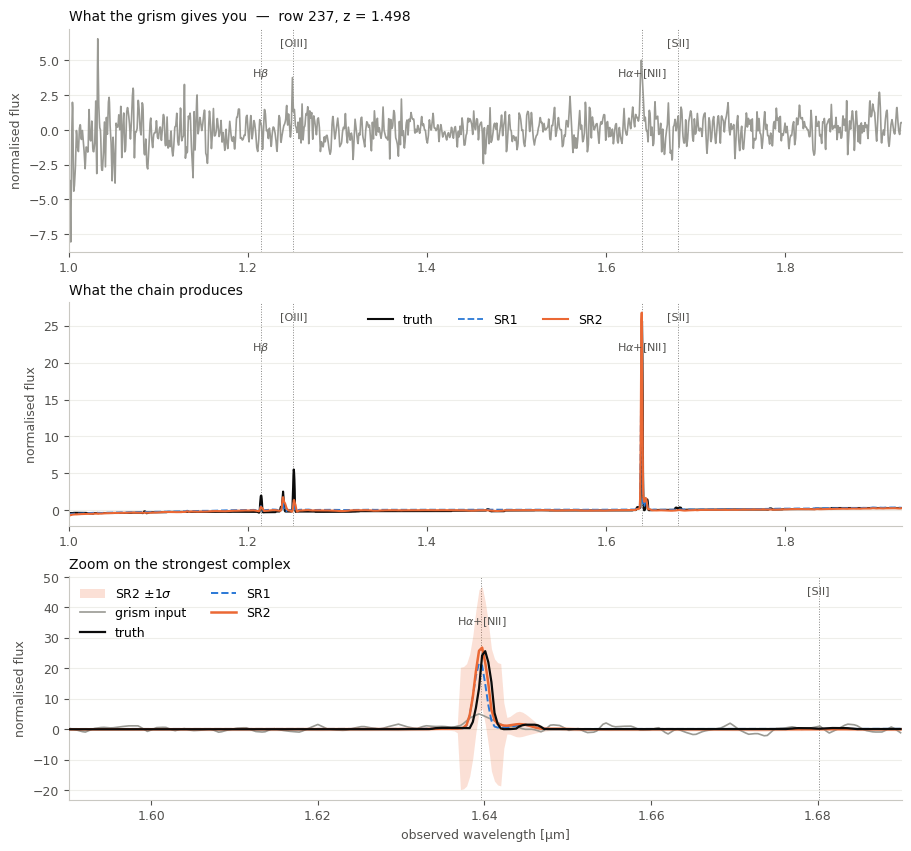

In [10]:
wave_um = WAVE_HR * 1e-4
peak = wave_um[np.argmax(truth_n)]
zoom = (peak - 0.05, peak + 0.05)


def mark_lines(ax, lo, hi):
    # Stagger the labels: at grism redshifts these complexes sit close together.
    for n, (name, rest) in enumerate(LABEL_LINES_AA):
        lam = rest * (1 + z_true[i]) * 1e-4
        if lo < lam < hi:
            ax.axvline(lam, color=MUTED, lw=0.7, ls=":", alpha=0.7, zorder=0)
            ax.annotate(name, (lam, 0.96 - 0.13 * (n % 2)),
                        xycoords=("data", "axes fraction"), ha="center",
                        va="top", fontsize=8, color=MUTED)


fig, axes = plt.subplots(3, 1, figsize=(9, 8.4), constrained_layout=True)
full = (wave_um >= 1.0) & (wave_um <= 1.93)

# 1. What the instrument gives you.
axes[0].plot(wave_um[full], lr_n[full], color=LR_GREY, lw=1.2)
axes[0].set_title(f"What the grism gives you  —  row {i}, z = {z_true[i]:.3f}",
                  color=INK, loc="left")

# 2. What the chain produces, against the noiseless truth.
axes[1].plot(wave_um[full], truth_n[full], color=INK, lw=1.5, label="truth")
axes[1].plot(wave_um[full], sr1_n[full], color=SR1_BLUE, lw=1.3, ls="--",
             label="SR1")
axes[1].plot(wave_um[full], sr2_n[full], color=SR2_ORANGE, lw=1.5, label="SR2")
axes[1].set_title("What the chain produces", color=INK, loc="left")
axes[1].legend(loc="upper center", ncols=3)

# 3. The strongest complex, with SR2's own uncertainty.
m = (wave_um >= zoom[0]) & (wave_um <= zoom[1])
axes[2].fill_between(wave_um[m], (sr2_n - sigma_n)[m], (sr2_n + sigma_n)[m],
                     color=SR2_ORANGE, alpha=0.20, lw=0, zorder=1,
                     label="SR2 $\\pm 1\\sigma$")
axes[2].plot(wave_um[m], lr_n[m], color=LR_GREY, lw=1.2, zorder=2,
             label="grism input")
axes[2].plot(wave_um[m], truth_n[m], color=INK, lw=1.6, zorder=5, label="truth")
axes[2].plot(wave_um[m], sr1_n[m], color=SR1_BLUE, lw=1.4, ls="--", zorder=3,
             label="SR1")
axes[2].plot(wave_um[m], sr2_n[m], color=SR2_ORANGE, lw=1.8, zorder=4,
             label="SR2")
axes[2].set_title("Zoom on the strongest complex", color=INK, loc="left")
axes[2].set_xlim(*zoom)
axes[2].legend(loc="upper left", ncols=2)
axes[2].set_xlabel("observed wavelength [µm]")

for ax, (lo, hi) in zip(axes, [(1.0, 1.93), (1.0, 1.93), zoom]):
    ax.set_xlim(lo, hi)
    ax.set_ylabel("normalised flux")
    ax.grid(axis="y", alpha=0.7)
    ax.set_axisbelow(True)
    mark_lines(ax, lo, hi)
plt.show()

The three panels have **different y-scales, on purpose**. Each spectrum is
normalised by its own mean and standard deviation, and the input's standard
deviation is set by its noise while the target's is set by its continuum. So a
line that is a modest bump in panel 1 is a tall spike in panel 2 even though
nothing was added — putting them on one axis would imply a calibration between
them that does not exist.

Read panel 3. SR1 (blue) is deliberately cautious and under-shoots the
amplitude; SR2 (orange) sharpens it toward the truth. The shaded band is SR2's
own per-pixel uncertainty, and it is *wide* here — the model is telling you it
knows the line is there but not exactly how bright. That is the intended
behaviour: the alternative is a confident wrong amplitude.

What neither stage does is add lines elsewhere in the band. That restraint is
the whole design, and section 6 is where it gets measured.

## 4. The redshift is a PDF, not a number

Redshift from a grism is a line-*identification* problem. A single observed line
is consistent with Hα, [O III], [O II] or Lyα, and a model that returns one
number has to average between those alternatives — which is how you get a
confidently wrong answer. Two earlier designs of this head did exactly that, and
both sat at a ~40 % catastrophic floor.

The ZHead returns a distribution over a grid instead. `out.z` is its **mode**;
`out.pz` is the whole thing. Keep the PDF.

mode 1:  z = 1.510   mass = 1.000
mode 2:  z = 1.427   mass = 0.000
mode 3:  z = 0.491   mass = 0.000

true z = 1.498


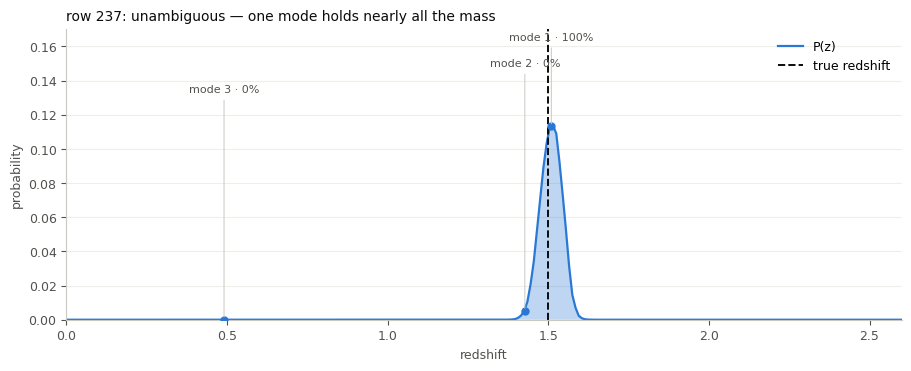

In [11]:
def top_modes(result, n=3):
    # The package's own mode finder -- the same hypotheses SR2 is run on.
    # It suppresses +/-15 grid bins around each pick, so the modes are distinct
    # line-alias candidates rather than adjacent bins of one peak, and weights
    # each by the probability *mass* in its window rather than by a bin height.
    zs, ws = topk_modes(torch.tensor(result.pz)[None, :],
                        torch.tensor(result.z_grid), n)
    return list(zip(zs[0].tolist(), ws[0].tolist()))


def plot_pz(result, truth, title):
    fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
    ax.fill_between(result.z_grid, result.pz, color=SR1_BLUE, alpha=0.30, lw=0)
    ax.plot(result.z_grid, result.pz, color=SR1_BLUE, lw=1.6, label="P(z)")
    ax.axvline(truth, color=INK, lw=1.4, ls="--", label="true redshift")
    # Stagger the mode labels by rank with a leader line: adjacent aliases sit
    # close enough in z that centred labels would overlap.
    for rank, (zm, mass) in enumerate(top_modes(result), start=1):
        height = result.pz[np.argmin(np.abs(result.z_grid - zm))]
        ax.plot([zm], [height], marker="o", ms=5, color=SR1_BLUE, zorder=3)
        ax.annotate(f"mode {rank} · {mass:.0%}", xy=(zm, height),
                    xytext=(zm, 1.05 - 0.09 * rank),
                    textcoords=("data", "axes fraction"), ha="center",
                    fontsize=8, color=MUTED,
                    arrowprops=dict(arrowstyle="-", lw=0.7, color="#c9c8c2"))
    ax.set_xlim(0, 2.6)
    ax.set_ylim(0, result.pz.max() * 1.5)     # headroom for the mode labels
    ax.set_xlabel("redshift")
    ax.set_ylabel("probability")
    ax.set_title(title, color=INK, loc="left")
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.7)
    ax.set_axisbelow(True)
    plt.show()


for rank, (zm, mass) in enumerate(top_modes(out), start=1):
    print(f"mode {rank}:  z = {zm:.3f}   mass = {mass:.3f}")
print(f"\ntrue z = {z_true[i]:.3f}")

plot_pz(out, z_true[i], f"row {i}: unambiguous — one mode holds nearly all the mass")

That galaxy is the easy case: one mode carries almost all the probability mass,
it sits on the truth, and `z_err` is correspondingly small. The two remaining
modes are the leftovers after suppression — real but negligible.

Section 5 finds the interesting case.

## 5. Photometry, and why it must be noisy

Three broadband colours break most of the alias degeneracy, which is the entire
reason the redshift head takes photometry at all. But the catalogue photometry
in this dataset is **noiseless truth**, and a metric measured on noiseless truth
photometry is not a metric. `apply_phot_noise` adds the same 0.05 mag jitter the
head was trained with.

We run the whole subset three ways: with realistic photometry, with the
noiseless catalogue values, and with none.

In [12]:
gen = torch.Generator().manual_seed(0)         # seeded, so the run reproduces
phot_noisy = apply_phot_noise(torch.tensor(phot_true, dtype=torch.float32),
                              0.05, gen).numpy()


def run_chain(phot, batch=64):
    results = []
    for s in range(0, len(flux_low), batch):
        p = None if phot is None else phot[s:s + batch]
        results += pipe.predict(flux_low[s:s + batch],
                                flux_low_err[s:s + batch], phot=p)
    return results


outs = run_chain(phot_noisy)
outs_clean = run_chain(phot_true)
outs_nophot = run_chain(None)
print(f"{len(outs)} spectra through the chain, three ways")

512 spectra through the chain, three ways


In [13]:
configs = {
    "grism + Roman imaging, 0.05 mag noise": outs,
    "grism + noiseless catalogue photometry": outs_clean,
    "grism only (photometry mean-imputed)": outs_nophot,
}

print(f"{'configuration':40s} {'NMAD':>8s} {'med |dz|':>9s} {'catastrophic':>13s}")
for label, res in configs.items():
    m = redshift_summary(np.array([r.z for r in res]), z_true)
    print(f"{label:40s} {m['nmad']:8.4f} {m['median_abs_dz']:9.4f} "
          f"{m['catastrophic_frac']:12.1%}")

configuration                                NMAD  med |dz|  catastrophic
grism + Roman imaging, 0.05 mag noise      0.0068    0.0046         6.1%
grism + noiseless catalogue photometry     0.0064    0.0046         4.7%
grism only (photometry mean-imputed)       0.0219    0.0152        27.5%


The first row is the deployable configuration, and it lands on the published
numbers (NMAD 0.0065 and 5.1 % catastrophic on the full 7,334-row test split;
this is a 512-row draw from it, so expect a little scatter).

Two cautions on the other two rows.

**The noiseless row is barely better than the noisy one.** That is the *point*
of restricting to three bands: three broadband colours are not a complete SED,
so there is very little for the head to cheat with. Hand a redshift head a
catalogue's every filter with no noise and it stops needing the spectrum at
all, and the score stops describing the instrument.

**`phot=None` is not a grism-only model.** The head was trained with photometry,
so passing `None` feeds it its training-mean colours: an out-of-distribution
input, not a clean ablation of the information. Read that row as "the colour
prior is carrying most of the redshift accuracy", not as a measurement of the
grism-only information floor. That floor is set by physics — with one line in
band the identification is genuinely alias-degenerate — and pinning it down
would take a head trained without colours, which is a separate experiment.

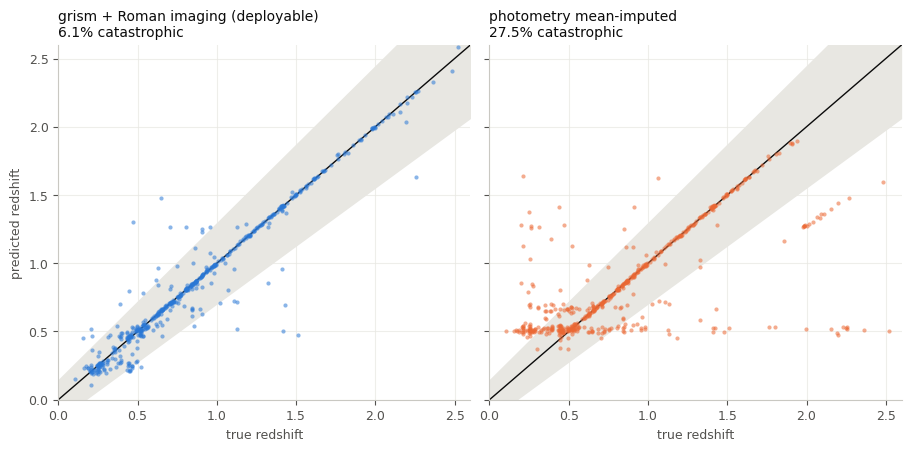

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4), constrained_layout=True,
                         sharex=True, sharey=True)
zline = np.linspace(0, 2.6, 200)

for ax, (label, res, colour) in zip(axes, [
        ("grism + Roman imaging (deployable)", outs, SR1_BLUE),
        ("photometry mean-imputed", outs_nophot, SR2_ORANGE)]):
    zp_i = np.array([r.z for r in res])
    frac = np.mean(np.abs(zp_i - z_true) / (1 + z_true) > 0.15)
    ax.fill_between(zline, zline - 0.15 * (1 + zline), zline + 0.15 * (1 + zline),
                    color="#e8e7e2", lw=0, zorder=0)
    ax.plot(zline, zline, color=INK, lw=1.0, zorder=1)
    ax.scatter(z_true, zp_i, s=9, color=colour, alpha=0.55, lw=0, zorder=2)
    ax.set_title(f"{label}\n{frac:.1%} catastrophic", color=INK, loc="left")
    ax.set_xlabel("true redshift")
    ax.set_xlim(0, 2.6)
    ax.set_ylim(0, 2.6)
    ax.grid(alpha=0.7)
    ax.set_axisbelow(True)

axes[0].set_ylabel("predicted redshift")
plt.show()

The shaded corridor is the ±0.15 catastrophic boundary, and the two panels fail
in visibly different ways.

On the left the failures are not scattered noise: they cluster at particular
(true, predicted) pairs — systematic line misidentifications, each cluster one
alias. On the right a **horizontal track** appears, where the head, deprived of
colour, falls back on its prior and returns nearly the same redshift regardless
of the input. Both are structure a point estimate hides and a PDF exposes.

### When the point estimate is wrong

Below we take one of those catastrophic outliers and ask what its PDF was
actually saying.

31 catastrophic outliers out of 512
18 of them have the truth as their second mode

row 302:  true z = 0.904,  point estimate = 1.230 (z_err = 0.201)
  mode 1:  z = 1.230   mass = 0.456
  mode 2:  z = 0.841   mass = 0.483  <- the truth
  mode 3:  z = 0.968   mass = 0.038  <- the truth


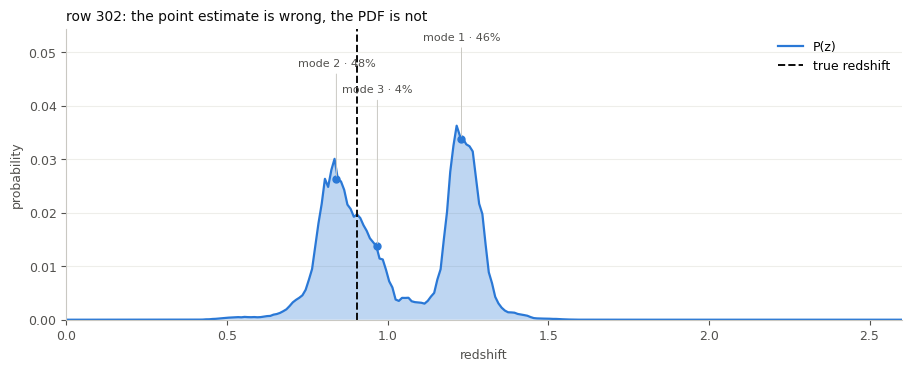

In [15]:
zp = np.array([r.z for r in outs])
bad = np.where(np.abs(zp - z_true) / (1 + z_true) > 0.15)[0]
print(f"{len(bad)} catastrophic outliers out of {len(zp)}")


def truth_rank(row):
    # Which mode, if any, landed on the true redshift.
    for rank, (zm, _) in enumerate(top_modes(outs[row])):
        if abs(zm - z_true[row]) / (1 + z_true[row]) < 0.05:
            return rank
    return None


# Of the failures whose *second* mode is the right answer, show the one where
# that runner-up carries the most mass -- the clearest instance of the pattern.
runners_up = [r for r in bad if truth_rank(r) == 1]
k = max(runners_up, key=lambda r: top_modes(outs[r])[1][1])
modes = top_modes(outs[k])

print(f"{len(runners_up)} of them have the truth as their second mode\n")
print(f"row {k}:  true z = {z_true[k]:.3f},  point estimate = {zp[k]:.3f} "
      f"(z_err = {outs[k].z_err:.3f})")
for rank, (zm, mass) in enumerate(modes, start=1):
    flag = ("  <- the truth"
            if abs(zm - z_true[k]) / (1 + z_true[k]) < 0.05 else "")
    print(f"  mode {rank}:  z = {zm:.3f}   mass = {mass:.3f}{flag}")

plot_pz(outs[k], z_true[k],
        f"row {k}: the point estimate is wrong, the PDF is not")

This is why `out.pz` is worth keeping. The point estimate is the **tallest
bin**, but the runner-up mode carries *more probability mass* than it does: the
model is not confidently wrong here, it is genuinely split between two readings
of the same line, and `z_err` is wide because of it.

A pipeline that propagates the PDF can act on that — deprioritise the source,
or carry both hypotheses forward. One that stores only `z` cannot tell this
source apart from a confident, narrow, correct one.

SR2 uses the same information: it runs once per redshift hypothesis and combines
by mode mass, so when the top mode is wrong the right lines still get drawn, at
reduced weight.

## 6. Line recovery, split by recoverability

Here is the metric that matters, and the reason it is shaped the way it is.

A single averaged "how much line flux did you recover" number can be improved
two ways: by getting better, or by hallucinating harder. Those are opposite
behaviours, and no average distinguishes them. So the score is **binned by
whether the line was recoverable from the low-resolution data at all**, using
the per-line integrated S/N labels loaded in section 3:

| bin | integrated line S/N | what it tests |
|---|---|---|
| `unrecoverable` | < 1 | **the control** — a good model scores ≈ 0 here |
| `marginal` | 1 – 3 | the hard, interesting regime |
| `good` | 3 – 6 | should be recovered |
| `strong` | > 6 | should be recovered well |

A model scoring 0.85 in `strong` *and* 0.85 in `unrecoverable` would be
worthless, and a single averaged metric would call it the better model. Read the
first row first.

In [16]:
truth_all = np.stack([ds[j][1].numpy() for j in range(len(ds))])
sr1_all = np.stack([to_model_space(r.flux_sr1, flux_low[j])
                    for j, r in enumerate(outs)])
sr2_all = np.stack([to_model_space(r.flux_sr, flux_low[j])
                    for j, r in enumerate(outs)])

rec = {stage: line_amplitude_recovery(pred, truth_all, ds.line_snr.numpy())
       for stage, pred in (("SR1", sr1_all), ("SR2", sr2_all))}

bins = list(rec["SR1"])
print(f"{'recoverability':16s} {'n':>5s} {'SR1':>8s} {'SR2':>8s}")
for b in bins:
    print(f"{b:16s} {rec['SR1'][b]['n']:5d} "
          f"{rec['SR1'][b]['median']:8.2f} {rec['SR2'][b]['median']:8.2f}")

recoverability       n      SR1      SR2
unrecoverable       71    -0.04     0.00
marginal           154     0.13     0.44
good                58     0.65     0.82
strong              30     0.63     0.75


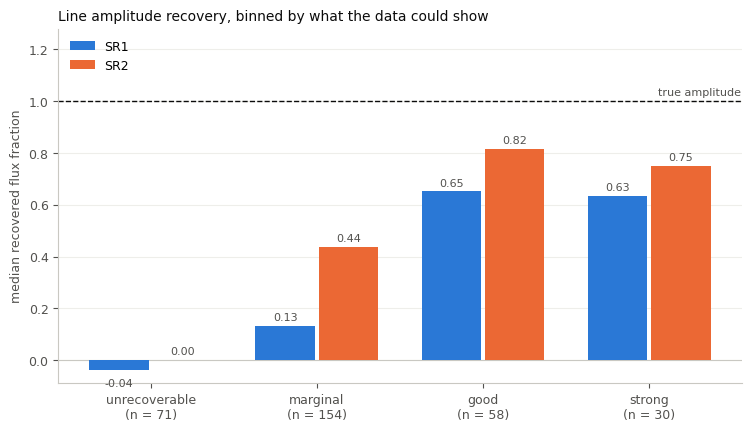

In [17]:
fig, ax = plt.subplots(figsize=(7.4, 4.2), constrained_layout=True)
x = np.arange(len(bins))
w = 0.36

for off, stage, colour in ((-w / 2 - 0.01, "SR1", SR1_BLUE),
                           (w / 2 + 0.01, "SR2", SR2_ORANGE)):
    vals = [rec[stage][b]["median"] for b in bins]
    ax.bar(x + off, vals, w, color=colour, label=stage, zorder=2)
    for xi, v in zip(x + off, vals):
        ax.annotate(f"{v:.2f}", (xi, v), textcoords="offset points",
                    xytext=(0, 4 if v >= 0 else -12), ha="center",
                    fontsize=8, color=MUTED)

ax.axhline(1.0, color=INK, lw=1.0, ls="--", zorder=1)
ax.annotate("true amplitude", (len(bins) - 0.45, 1.0),
            textcoords="offset points", xytext=(0, 4), ha="right",
            fontsize=8, color=MUTED)
ax.axhline(0, color="#c9c8c2", lw=0.8, zorder=1)
ax.set_ylim(top=1.28)
ax.set_xticks(x)
ax.set_xticklabels([f"{b}\n(n = {rec['SR1'][b]['n']})" for b in bins])
ax.set_ylabel("median recovered flux fraction")
ax.set_title("Line amplitude recovery, binned by what the data could show",
             color=INK, loc="left")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.7)
ax.set_axisbelow(True)
plt.show()

This reproduces the published pattern on a 512-row draw. SR2 sharpens
recoverable lines substantially toward truth — and leaves the undetectable ones
at essentially zero. The leftmost pair is the one to check on any model you
train yourself: a bar that climbs *there* is a model inventing lines, however
good the rightmost pair looks.

SR1's `unrecoverable` bar sits slightly below zero. That is a conservative model
declining to draw, not an error.

### Per-line presence probabilities

SR2 also emits a presence probability for each of its 98 rest-frame features.
For the example galaxy from section 3:

In [18]:
rest_aa = dict(LINE_LIST_REST_AA)

print(f"{'feature':22s} {'p':>5s}   observed")
for j in np.argsort(out.presence)[::-1][:8]:
    name = out.line_names[j]
    lam_obs = rest_aa[name] * (1 + z_true[i])
    where = (f"{lam_obs * 1e-4:.3f} µm" if 10000 < lam_obs < 19300
             else "out of band")
    print(f"{name:22s} {out.presence[j]:5.2f}   {where}")

feature                    p   observed
[NII]_6548              0.93   1.636 µm
Halpha_6563             0.89   1.640 µm
[OIII]_5007             0.73   1.251 µm
[OIII]_4959             0.69   1.239 µm
[NII]_6583              0.66   1.645 µm
Hbeta_4861              0.61   1.215 µm
[SIII]_9531             0.23   out of band
[FeII]_16435            0.21   out of band


Features falling outside the grism band are gated off in SR2's line branch, so a
high presence probability there costs nothing and means nothing — read this list
together with the observed wavelength.

## 7. From the command line

Everything above has a CLI equivalent, which is usually what you want for a
catalogue rather than for a notebook.

In [19]:
!specsr-roman info

specsr-roman 0.1.0
torch 2.11.0+cu128 | cuda available: False
hub repo: aryana-haghjoo/roman-spectral-superresolution
canonical chain:
  sr1    sr1_ou2024_v6
  zhead  zhead_ou2024_roman_med3_noisy
  sr2    sr2_ou2024_v5_romanonly


  extra [extract]: ok


  extra [train]: ok
  extra [hub]: ok


```bash
# run the chain over an npz holding flux_low[, flux_low_err, phot, wavelength_low]
specsr-roman predict spectra.npz --out predictions.npz --phot-tier medium

# reproduce the published metrics and figures from a frozen prediction cache
specsr-roman evaluate cache   --out pred_cache.npz
specsr-roman evaluate metrics --cache pred_cache.npz
specsr-roman evaluate figures --outdir figures/

# the audit that keeps the line-recovery claims honest
specsr-roman evaluate prior
```

Training each stage is one command and one config file:

```bash
specsr-roman train sr1   --config configs/sr1.yaml
specsr-roman train zhead --config configs/zhead.yaml     # needs SR1
specsr-roman train sr2   --config configs/sr2.yaml       # needs SR1 + ZHead
```

## 8. Where to go next

- **[Quickstart](https://aryana-haghjoo.github.io/specsr-roman/guides/quickstart.html)**
  — the same API in reference form.
- **[Data guide](https://aryana-haghjoo.github.io/specsr-roman/guides/data.html)**
  — the full dataset, the splitting rule, and the photometric tiers.
- **[Training guide](https://aryana-haghjoo.github.io/specsr-roman/guides/training.html)**
  — including why SR2's best epoch is 4, which is the design working rather than
  a truncated run.
- **[Evaluation guide](https://aryana-haghjoo.github.io/specsr-roman/guides/evaluation.html)**
  — the metrics above, plus the prior-dominance audit.
- **`ARCHITECTURE.md`** — the full design, the losses, and why each one is
  shaped the way it is.

### Before you use this on anything real

- **These results are on a simulation's manifold.** Targets are Diffsky model
  SEDs with that simulation's line physics. A model can score well by learning
  the manifold rather than by measuring anything, and no reconstruction metric
  distinguishes the two — which is why the package ships a prior-dominance
  audit. The published SR1 sits at r ≈ 0.45: it reads the data about half as
  much as it could.
- **Trained on simulations, not sky.** Real Roman spectra will differ, and
  domain adaptation is open work.
- **The catastrophic rate is physics, not a bug to tune away.** With a single
  line in band the identification is genuinely ambiguous. Photometry breaks most
  of that degeneracy and cannot break all of it — so propagate the PDF.